In [29]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import time

import astropy.units as u
import astropy.cosmology.units as cu
import astropy.constants as const

import raytrace

rng = np.random.default_rng()

colors = ['red', 'orangered','yellowgreen', 'royalblue', 'blueviolet']
cm_kpc = u.cm.to(u.kpc)
cm_kpc

with h5py.File("outputs/dm_proto_mstar_weighted.hdf5", "r") as f:
    halo_ids = list(f.keys())
halo_ids = np.array([int(id[5:]) for id in halo_ids[3:]])

with h5py.File("outputs/dm_proto_mstar_weighted.hdf5", "r") as f:
    good_halo_ids = list()
    halo_m500 = list()
    halo_fgas500 = list()
    halo_fgas500_max = list()

    for halo_id in halo_ids:
        halo = f['halo_' + str(halo_id)]    
        if 'trace' not in halo:
            continue
        if 'Group_Fgas_Crit500' not in halo:
            continue

        good_halo_ids.append(halo_id)

        # halo_mass.append(np.sum(halo['GroupMassType'][:]))
        halo_fgas500.append(halo['Group_Fgas_Crit500'][()])
        halo_m500.append(halo['Group_M_Crit500'][()])
        halo_fgas500_max.append(halo['Group_Fgas_Crit500_max'][()])
        # plt.scatter(trace['star_pos'][:, 0], trace['star_pos'][:, 1])
    # print(impact.shape, dm.shape)
good_halo_ids = np.array(good_halo_ids)
halo_m500 = np.array(halo_m500)
halo_fgas500 = np.array(halo_fgas500)
halo_fgas500_max = np.array(halo_fgas500_max)

Text(0, 0.5, 'Fgas500c')

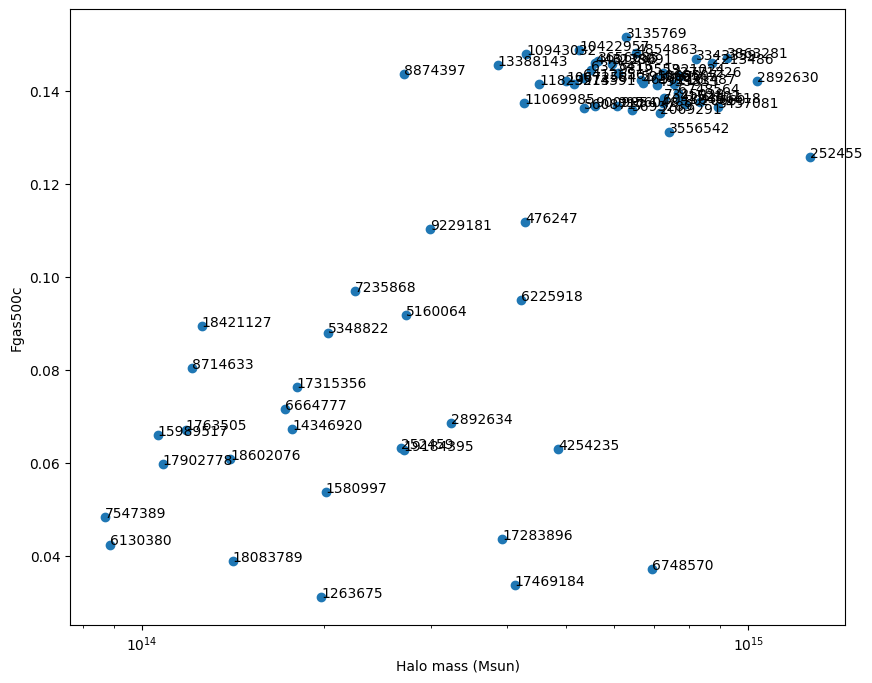

In [27]:
xs = 1e10*halo_m500
ys = halo_fgas500
plt.figure(figsize=(10,8))
plt.scatter(xs, ys)
for (j,x,y) in zip(good_halo_ids,xs,ys):
    plt.text(x,y,j)

plt.semilogx()
plt.xlabel('Halo mass (Msun)')
plt.ylabel('Fgas500c')


Text(0, 0.5, 'upper bound on Fgas500c')

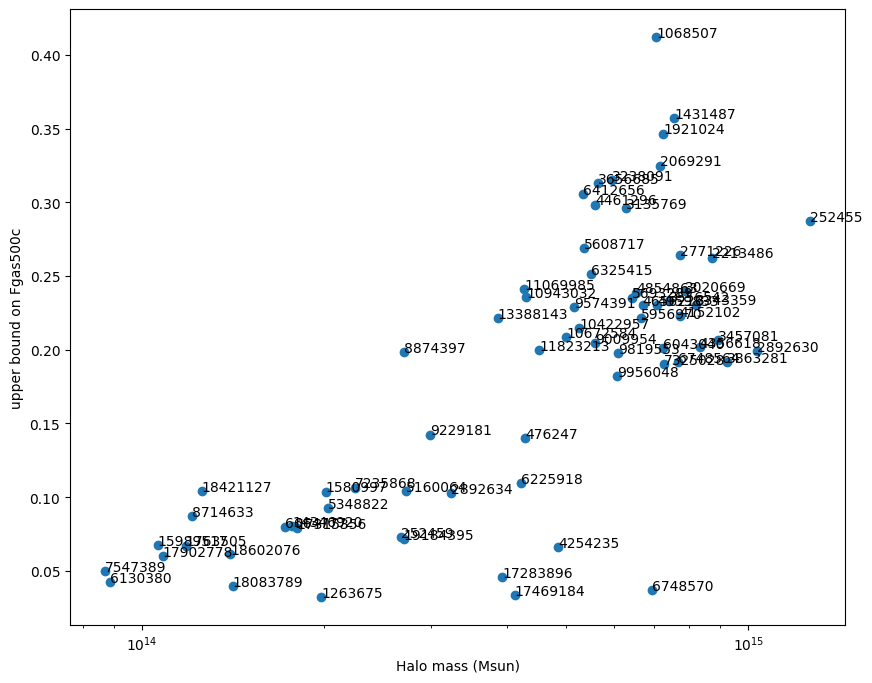

In [31]:
xs = 1e10*halo_m500
ys = halo_fgas500_max
plt.figure(figsize=(10,8))
plt.scatter(xs, ys)
for (j,x,y) in zip(good_halo_ids,xs,ys):
    plt.text(x,y,j)

plt.semilogx()
plt.xlabel('Halo mass (Msun)')
plt.ylabel('upper bound on Fgas500c')


17469184
0.03375737257890871


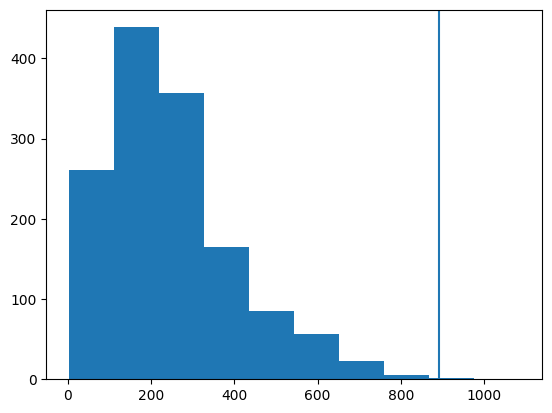

In [22]:
import numpy as np
import h5py
import time

import astropy.units as u
import astropy.cosmology.units as cu
import astropy.constants as const
import matplotlib.pyplot as plt
import raytrace
import sys

rng = np.random.default_rng(seed=1)

repeat = True

with h5py.File("outputs/dm_proto.hdf5", "r") as f:
    halo_ids = list(f.keys())

halo_id = '17469184'
print(halo_id)

with h5py.File("outputs/dm_proto.hdf5", "r") as f:
    halo = f['halo_'+halo_id]
    com = halo['GroupCM'][:]
    halo_pos = halo['GroupPos'][:]
    halo_masses = halo['GroupMassType'][:]

    r200 = halo['Group_R_Crit200'][()]
    r500 = halo['Group_R_Crit500'][()]
    
    m200 = halo['Group_M_Crit200'][()]
    m500 = halo['Group_M_Crit500'][()]

    # subs = halo['subhalos']
    # sub0_cm = np.array([ subs['cm_x'][0], subs['cm_y'][0], subs['cm_z'][0] ]).T

with h5py.File(f'tng_cache/snap_099/cutout_{halo_id}.hdf5', 'r') as f:
    gas_pos = raytrace.unwrap(f['PartType0/Coordinates'][:] - halo_pos) # ckpc
    gas_mass = f['PartType0/Masses'][:] # Msun
    
    eta_e = f['PartType0/ElectronAbundance'][:] # fraction
    X_H = f['PartType0/GFM_Metals'][:,0] # fraction
    gas_m_e = gas_mass * eta_e * X_H # Msun

r = np.linalg.norm(gas_pos, axis=-1)
fgas200 = np.sum(gas_mass[r < r200])/m200
fgas500 = np.sum(gas_mass[r < r500])/m500
fe200 = np.sum(gas_m_e[r < r200])/m200
fe500 = np.sum(gas_m_e[r < r500])/m500

print(fgas500)
plt.hist(r, weights=gas_mass)
plt.axvline(r500)

In [14]:
np.sum(gas_mass)

np.float32(1392.4758)

In [25]:
halo_masses[0]/m500

np.float64(0.0338012421613753)